In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容
from extraction import find_一般政策语言_rule_base
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

/Users/ender_yang/opt/anaconda3/envs/lainchain/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

def find_权宜处理_rule_base(docs, 一般政策性内容):
    """
    Return the sentences that match 权宜处理 keywords using regular expression and fuzzy matching.

    Returns:
        list of tuple: The sentences that match 权宜处理 keywords and the matched keywords.
        list of tuple: The index of the matched sentences in the original text and the matched keywords.
    """
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # We need to standardize the 一般政策性内容 to avoid any characters at the beginning of the sentence
    一般政策性内容 = standerlize_一般政策性内容(一般政策性内容)
    
    # Define keywords for regular expression
    keywords = ["结合.*?实际", "根据.*?实际", "因地制宜"]
    pattern = re.compile('|'.join(keywords))
    
    # Define keywords for fuzzy matching
    keywords_fuzzy = ["结合实际", "根据实际", "根据实际情况", "结合实际情况", "结合本地实际", "根据本地实际"]
    
    # Preprocess the document to separate it into paragraphs
    paragraphs = pre_process(docs)

    matched_paragraphs = []

    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        # Check if the paragraph is in 一般政策性内容
        clean_paragraph = re.sub(r'\s+', '', paragraph)
        if clean_paragraph in 一般政策性内容:
            continue
        
        match = pattern.search(paragraph)
        if match:
            matched_paragraphs.append((paragraph.strip(), match.group()))
        else:
            best_match = process.extractOne(paragraph, keywords_fuzzy)
            if  best_match[1] >= 60:
                matched_paragraphs.append((paragraph.strip(), best_match[0]))

    # Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_权宜处理_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[15]
docs = open(f'sample/{file_sample}', 'r').read()

$\textbf{Since we need 一般政策性内容 content, so we first extract 一般政策性内容}$

In [5]:
def get_一般政策语言(docs):
    matched_paragraphs_一般政策语言, _ = find_一般政策语言_rule_base(docs)
    一般政策语言_list = []
    for 一般政策语言, _ in matched_paragraphs_一般政策语言:
        一般政策语言_list += [一般政策语言]
        
    return 一般政策语言_list

In [6]:
# we can check the 一般政策语言 content
一般政策语言_list = get_一般政策语言(docs)
print(一般政策语言_list)

['《贵阳市蔬菜基地建设保护办法》(以下简称《办法》)修订工作已列入市人大地方性法规修订2016年度计划中，根据《修订工作实施方案》安排，近期市人大农经委、市法制局、市农委将组织召开《办法》修订讨论会，会议将汇总各方面对现执行的《办法》存在的问题的意见，梳理《办法》修订建议，保证修订后的《办法》的科学性、指导性、实用性、前瞻性，现将会议有关事宜通知如下：\u3000\u3000一、会议时间：']


## Now we can call the function find_权宜处理_rule_base() ##

In [7]:
matched_paragraphs, matched_paragraphs_index = find_权宜处理_rule_base(docs, 一般政策语言_list)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [8]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason


$\textbf{We can also check where is the sentence}$

In [9]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.2014615
原文链接：https://www.pkulaw.com/lar/df1c60f08f78ba532dd5080fdf976011bdfb.html
贵阳市农业委员会办公室关于召开《贵阳市蔬菜基地建设保护办法》修订讨论会的通知
贵阳市农业委员会办公室关于召开《贵阳市蔬菜基地建设保护办法》修订讨论会的通知
筑农办通字[2016]14号
各区（市、县）农业（水）局（蔬菜办）、双龙临空经济区农业部门：
　　《贵阳市蔬菜基地建设保护办法》(以下简称《办法》)修订工作已列入市人大地方性法规修订2016年度计划中，根据《修订工作实施方案》安排，近期市人大农经委、市法制局、市农委将组织召开《办法》修订讨论会，会议将汇总各方面对现执行的《办法》存在的问题的意见，梳理《办法》修订建议，保证修订后的《办法》的科学性、指导性、实用性、前瞻性，现将会议有关事宜通知如下：　　一、会议时间：
　　2016年1月26日（星期二）上午9：30
　　二、会议地点
　　市农委第二会议室
　　三、参会人员
　　各区（市、县、双龙临空经济区）农业行政主管部门分管蔬菜基地建设的领导；蔬菜龙头企业（合作社）代表。
　　四、参会要求
　　提供书面汇报材料（电子档）：各地根据蔬菜产业发展现状及规划，整理现行《办法》存在的问题和修订意见，重点体现（1）《办法》中关于立法目标、基地面积、建设标准、保护措施等方面存在的问题及修订建议；（2）《办法》关于执法部门及其责任的规定合理性存在的问题及修订建议；（3）《办法》中的规定缺乏应有的可操作性的问题及修订建议；（4）新菜地开发建设基金征收工作的问题及建议。
贵阳市农业委员会办公室
2016年1月19日



## Now we can run batch processing on our sample data ##

In [10]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length', '一般政策语言'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        一般政策语言_list = get_一般政策语言(docs)
        
        matched_paragraphs, matched_paragraphs_index = find_权宜处理_rule_base(docs, 一般政策语言_list)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list), "\n".join(一般政策语言_list)]
    
    return return_df


In [11]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,,,558,0,为进一步提高我市城镇职工基本医疗保险参保人员血友病门诊特定病种医疗保险待遇，根据《佛山市城镇职工基本医疗保险门诊特定病种管理暂行办法》（佛劳社〔2007〕1108号）和《进一步完善城镇职工基本医疗保险有关问题的意见》（佛劳社[2009]143号）的有关规定，现将我市城镇职工基本医疗保险部分门诊特定病种规定如下：
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,,,1088,0,为了进一步推动我省示范基地的创建工作，加强对示范基地的培育、扶持和服务，现将《指导意见》转发给你们，请你们结合实际，贯彻落实好《指导意见》，为此，提出以下几点要求：
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,,,4274,0,为有效解决暂不具备市内迁移条件的本市户籍人员落户问题，经第5次市局局长办公会通过，现将《北京市公安局户籍派出所设立公共户工作规定（试行）》印发给你们，请认真贯彻执行
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,,,1298,0,贵单位提出的关于进一步加快数字文旅整合发展的建议收悉，现答复如下：
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,经深入调研，并经多行业专家论证，在征求自治区文化和旅游工作厅际联席会议成员单位意见建议后，我厅组织修订完成了《广西特色旅游名县创建工作管理办法（2019年修订）》和《广西特色旅游名县评定标准与评分细则（2019年修订）》，现印发你们，请结合实际，认真组织实施,结合实际,613,129,为进一步提高广西特色旅游名县创建工作的科学性、针对性和可操作性，促进文化和旅游融合发展，我厅对《广西特色旅游名县创建工作管理办法》和《广西特色旅游名县评定标准与评分细则》进行了修订


In [12]:
# We can check if the Retrieve Info is in 一般政策语言
for index, row in df.iterrows():
    if row['Retrieve Info'] == '':
        continue
    
    Retrieve_Info = row['Retrieve Info'].split('\n')
    一般政策语言 = row['一般政策语言'].split('\n')
    
    for info in Retrieve_Info:
        if info in 一般政策语言:
            print(info)

$\textbf{Here we provide some statistics on the results}$

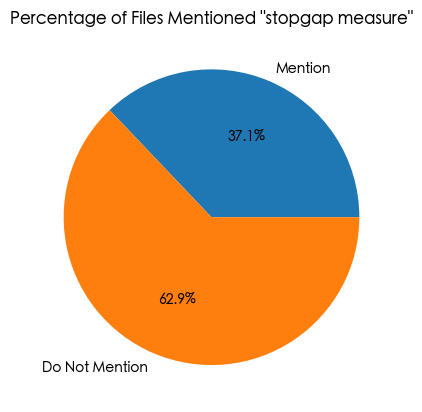

In [13]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "stopgap measure"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

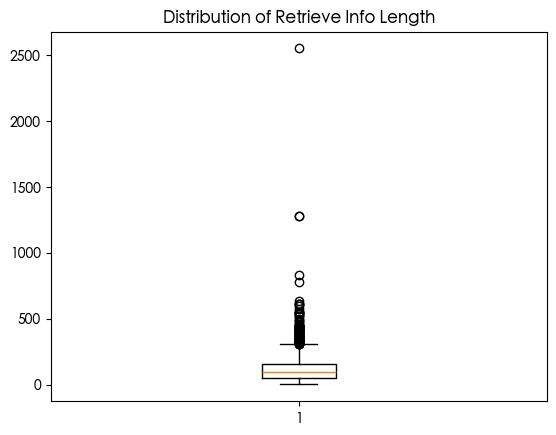

In [14]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

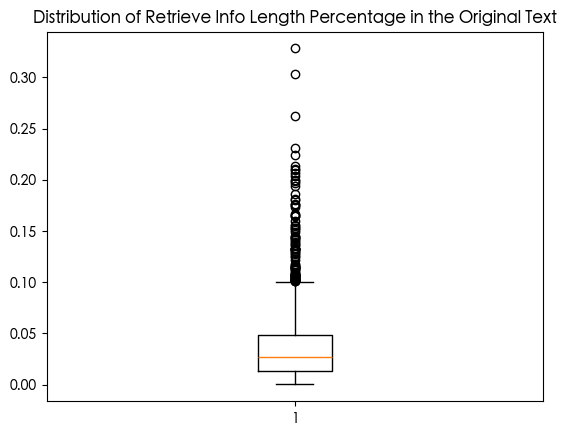

In [15]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [16]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
1003,上海市教育委员会关于印发本市中小学校幼儿园...(FBM-CLI.12.778911).txt,三、为完善学校自主管理、自我约束的体制机制，反映学校文化精神与办学特色，各学校在制定或修订章程时，可根据实际，结合学校发展，适当增减章、节、条、款、项的内容，适当调整章、节、条、款、项的顺序\n（说明：本条依据是2010年市委组织部、市教卫工作党委、市教委关于印发《关于进一步完善上海市中小学校校长负责制的若干意见》《上海市中小学校党组织工作意见》《上海市中小学校校长工作意见》《上海市中小学校教职工代表大会工作意见》的通知（沪教卫党〔2010〕147号），其中《上海市中小学校校长工作意见》对校长的主要职权有明确规定，学校可参照规定并结合实际情况表述\n（说明：本条依据是2010年市委组织部、市教卫工作党委、市教委关于印发《关于进一步完善上海市中小学校校长负责制的若干意见》《上海市中小学校党组织工作意见》《上海市中小学校校长工作意见》《上海市中小学校教职工代表大会工作意见》的通知（沪教卫党〔2010〕147号），其中《关于进一步完善上海市中小学校校长负责制的若干意见》对此有明确要求， 学校可参照规定并结合实际情况表述\n第十二条 【校务委员会】 学校根据办学实际需要，建立由教师、学生及家长代表参加的校务委员会，参与制定、审议学校章程、发展规划和其他规章制度、人事与财务方案等重大事项\n（说明：校务委员会作为校长负责制的补充和完善，是学校内部管理体制的重要组成部分，教育部《全面推进依法治校实施纲要》对建立校务委员会有明确要求，学校如建立校务委员会的，可结合实际情况表述\n（说明：教职工代表大会制度是各级各类学校实行民主管理与监督的基本形式，《学校教职工代表大会规定》（教育部令第32号）对此有明确要求，学校可结合实际情况表述\n（说明：学校可结合学校职能部门设置实际情况表述\n（说明：本条依据是《教育部关于推进中小学信息公开工作的意见》（教办〔2010〕15号）和教育部《全面推进依法治校实施纲要》的相关规定，学校可结合实际情况表述\n（说明：本条依据是教育部《全面推进依法治校实施纲要》的相关规定，学校可结合实际情况表述\n（说明：本条依据是《教育法》第四十二条，学校可结合实际情况表述\n（说明：本条依据是《教育法》第四十三条，学校可结合实际情况表述\n（说明：本条依据是《上海市中小学学籍管理办法》（沪教委基〔2006〕7号）、《上海市中等职业学校学生学籍管理实施办法》（沪教委职〔2010〕37号）及《上海市义务教育阶段学生学籍管理办法》（沪教委基〔2012〕65号）的相关规定，学校可结合实际情况表述\n（说明：本条依据是《上海市幼儿园、义务教育学校、普通高中、中等职业学校、教师进修院校岗位设置管理的实施办法》（沪教委人〔2010〕72号）的相关规定，学校可结合实际情况表述\n（说明：学校可结合实际情况表述\n（说明：学校可结合实际情况表述\n（说明：学校可结合实际情况表述\n（说明：本条依据是《教育部关于建立中小学幼儿园家长委员会的指导意见》（教基一〔2012〕2号），教育部《全面推进依法治校实施纲要》对建立家长委员会制度也有明确要求，学校如建立家长委员会的，可结合实际情况表述\n（说明：本条依据是教育部《全面推进依法治校实施纲要》的相关规定，学校可结合实际情况表述\n（说明：学校如建立校友会的，可结合实际情况表述\n第三十六条 【对外合作交流】 学校根据办学实际需要，开展校际互动合作，不断扩大对外交流，拓展教育视野，提升办学水平\n（说明：本条依据是《教育法》第七十条、七十一条的规定，学校可结合实际情况提出相应的保护措施\n（说明：本条依据是《中小学校财务制度》（财教〔2012〕489号），学校可结合实际情况表述\n（说明：本条依据是《教育法》第七十七条及《普通高级中学收费管理暂行办法》《中等职业学校收费管理暂行办法》（教财〔1996〕101号）的相关规定，学校可结合实际情况表述\n（说明：学校可结合实际情况确定章程修订的提出部门或人员\n（说明：学校可结合实际情况指定章程解释部门\n三、为完善幼儿园自主管理、自我约束的体制机制，反映幼儿园文化精神与办学特色，各幼儿园在制定或修订章程时，可根据实际，结合学校发展，适当增减章、节、条、款、项的内容，适当调整章、节、条、款、项的顺序\n（说明：本条依据是《幼儿园工作规程》第三十六条，幼儿园可结合实际情况表述\n（说明：本条依据是《幼儿园工作规程》第五十四条，幼儿园可结合实际情况表述\n（说明：教职工代表大会制度是各级各类学校、幼儿园实行民主管理与监督的基本形式，《学校教职工代表大会规定》（教育部令第32号）对此有明确要求，幼儿园可结合实际情况表述\n（说明：幼儿园可结合园内职能部门实际情况表述\n本园根据办园实际需要建立园务委员会，园务委员会由保教、医务、财会等人员的代表及家长的代表组成，参与审议上述决策事项\n（说明：本条依据是《幼儿园工作规程》第五十二条，有利于推进幼儿园决策的科学化、民主化、法治化，幼儿园如建立园务委员会的，可结合实际情况表述\n（说明：幼儿园可结合实际情况表述\n（说明：幼儿园可结合实际情况表述\n（说明：本条依据是《教育法》第四十二条，幼儿园可结合实际情况表述\n（说明：本条依据是《教育法》第四十三条，幼儿园可结合实际情况表述\n（说明：幼儿园可结合实际情况表述\n（说明：本条依据是《幼儿园工作规程》第四十九条，幼儿园可结合实际情况表述\n（说明：本条依据是《教育部关于建立中小学幼儿园家长委员会的指导意见》（教基一〔2012〕2号），教育部《全面推进依法治校实施纲要》对建立家长委员会制度也有明确要求，幼儿园如建立家长委员会的，可结合实际情况表述\n（说明：本条依据是《幼儿园工作规程》第五十一条，幼儿园可结合实际情况表述\n（说明：本条依据是《幼儿园工作规程》第四十七条及《会计法》的有关规定，幼儿园可结合实际情况表述\n（说明：本条依据是《幼儿园收费管理暂行办法》（发改价格〔2011〕3207号）的相关规定，幼儿园可结合实际情况表述\n（说明：本条依据是《教育法》第七十条、第七十一条，幼儿园可结合实际情况提出相应的保护措施\n（说明：幼儿园可结合实际情况确定章程修订的提出部门或人员\n（说明：幼儿园可结合实际情况指定章程解释部门,根据实际\n结合实际\n结合实际\n根据办学实际\n结合实际\n结合实际\n结合学校职能部门设置实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n根据办学实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n根据实际\n结合实际\n结合实际\n结合实际\n结合园内职能部门实际\n根据办园实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际\n结合实际,13171,2550,为贯彻落实教育部《全面推进依法治校实施纲要》，实现“到2015年，全面形成一校一章程的格局”要求，深入推进本市中小学校、幼儿园章程建设工作，市教委在总结以往章程建设经验的基础上，研究制定了上海市中小学校、幼儿园章程参考文本（见附件），现印发给你们，作为你们推进学校章程建设工作的指导和参考\n 第一章 总则\n 第一条 【制定目的与依据】 为规范学校内部管理体制和运行机制，推进学校依法治校，建设现代学校制度，…… 根据《中华人民共和国教育法》《中华人民共和国教师法》《全面推进依法治校实施纲要》等有关法律法规与规定，结合学校实际，制定本章程\n （说明：章程是中小学校内部管理和运行的基本依据，《教育法》第二十六条、第二十八条明确规定各级各类学校要有章程并按照章程自主管理，教育部《全面推进依法治校实施纲要》也将章程建设作为推进学校依法治校、建设现代学校制度的一项基础工作\n义务教育阶段学校、中等职业学校应在法律依据列举中分别增补《中华人民共和国义务教育法》《中华人民共和国职业教育法》等法律依据\n）\n 第二条 【学校名称与地址】 本校全称为 ；英文表述为 ；住所地址为 \n （说明：学校如有简称，应补充简称为“ ”，英文简写为“ ”\n住所地址按照《事业单位法人证书》上核准登记的内容填写，有多个校区，应逐个写明各校区地址，如有网址也应写明\n）\n 第三条 【学校性质及隶属关系】 本校由上海市 区（县）教育局举办，经登记批准，是具有法人资格的办学机构，独立承担民事责任\n本校是一所实施 年制（高中、初中、小学等）教育的全日制教育机构\n （说明：学校具有两方面属性：一是由教育行政部门举办的公共教育机构，具有公益性，二是经登记部门批准的事业单位法人，依法独立承担民事责任\n）\n 第四条 【招生对象与规模】 学校面向 招生，招生对象为 ，招生规模以 区（县）教育局核定的班级和人数为准\n （说明：中小学校招生对象、招生规模以教育行政主管部门核定为准\n）\n 第五条 【办学宗旨与使命】 ……\n （说明：学校应将办学核心理念、价值追求在本条予以凝炼概括，并适当展开阐释\n）\n 第六条 【学校发展目标】 ……\n （说明：学校应围绕办学宗旨，明确发展定位

In [17]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
1328,成都市卫生局关于转发《四川省卫生厅转发卫生...(FBM-CLI.12.1725272).txt,要高度重视，结合实际，认真按照《学校卫生监督工作规范》（以下简称《规范》）要求，进一步健全和完善学校卫生监督管理制度，加大学校卫生监管工作力度；依据属地化管理原则，对辖区内各级各类学校开展校舍新建、改建、扩建项目预防性卫生审查工作，从源头加强卫生预防性控制管理工作；加强日常监督检查，严格按照学校卫生监督职责的要求，做好对辖区内学校的卫生监督检查不少于2次/年，切实把《规范》全面的贯彻好、落实好，推进全省学校卫生监督工作规范有序地开展,结合实际,664,218,现将《四川省卫生厅转发卫生部的通知》转发你们，请认真遵照执行\n现将《卫生部关于印发〈学校卫生监督工作规范〉的通知》（卫监督发[2012]62号）转发你们,0.328313
4306,晋城市安全生产监督管理局转发省安监局《关于...(FBM-CLI.12.1892259).txt,为此省安监局下发了《关于深入开展化解钢铁行业过剩产能安全生产执法专项行动“回头看”检查的通知》（晋安监发〔2017〕267号），请各县（市、区）结合实际对辖区内相关企业进行“回头看”再检查，特别是国家安监总局“明察暗访”发现的两类事故隐患，并将排查整改情况于11月20日前上报市安监局一科，确保我市钢铁行业化解过剩产能过程中安全生产,结合实际,548,166,日前，国家安监总局在我省开展了冶金企业安全生产“明察暗访”督查检查，发现了包括“炼钢厂渣跨吊运液态渣的起重机不是冶金起重机和熔融金属吊运影响范围内存在热修作业区等人员聚集场所”两类突出隐患在内的148条隐患,0.302920
2875,厦门市民政局关于表彰2009－2010年度先进基层党组织...(FBM-CLI.12.6154736).txt,"2009年以来，局系统各级党组织和全体共产党员坚持以邓小平理论和“三个代表""重要思想为指导，认真落实科学发展观，深入贯彻党的十七大和十七届四中、五中全会精神，按照中央和省、市各项部署与要求，紧紧围绕服务海峡西岸经济区建设和我市打好“五大战役""、实现“四个新跨越""的大局，以加强党的执政能力建设，构建社会主义和谐社会为重点，紧密结合民政部门实际，围绕中心，服务大局，团结协作，奋力拼搏，认真落实党建和党风廉政建设责任制，牢固树立“以民为本、为民解困、为民服务""的核心理念，切实履行“解决民生、落实民权、维护民利""的核心职责，全面加强和改进党的思想、组织、作风、制度和反腐倡廉建设，充分发挥基层党组织的战斗堡垒作用和共产党员的先锋模范作用，党的创造力、凝聚力和战斗力不断增强，党员干部为民服务、为民解困意识不断提高，工作效能不断提升，党建工作和中心工作紧密结合，为保障民生、发展民主、服务社会、维护稳定、增进和谐做出了积极贡献，涌现出一批思想解放、工作扎实、成绩优异的先进基层党组织和优秀共产党员、优秀党务工作者、优秀纪检委员",结合民政部门实际,1755,461,"为树立典型、弘扬正气，激励各级党组织和广大共产党员更好地贯彻党的十七大和十七届四中、五中全会精神，不断深化创先争优活动，全面推进局系统党的建设，落实市委、市政府完成“五个翻番""、打造“五个厦门""、实现“四个新跨越""的目标，在服务大局中实现“十二五""民政事业大发展，在纪念中国共产党成立90周年之际，经局直属党委研究确定，局党组审定：授予莲坂军休所党总支等5个党组织“先进基层党组织""称号；授予曾小聪等25位同志“优秀共产党员""称号；授予左丽华等5位同志“优秀党务工作者""称号；授予石好荣等4位同志“优秀纪检委员""称号",0.262678


## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [18]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

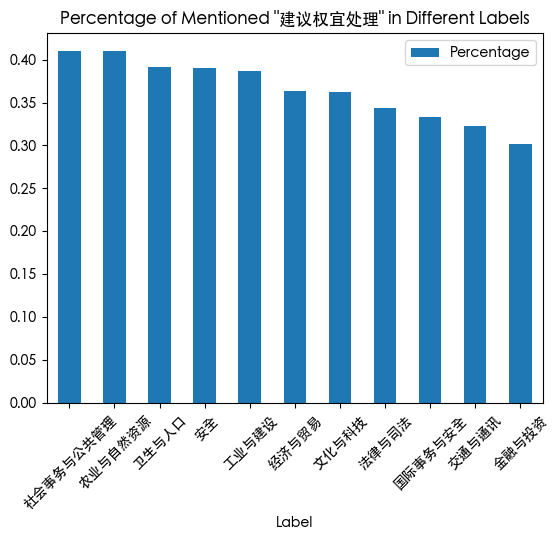

In [19]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "建议权宜处理" in Different Labels')
plt.xticks(rotation=45)
plt.show()

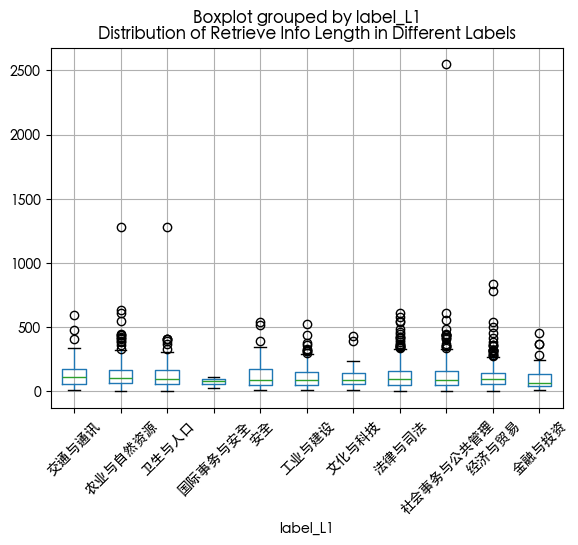

In [20]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=45)
plt.show()

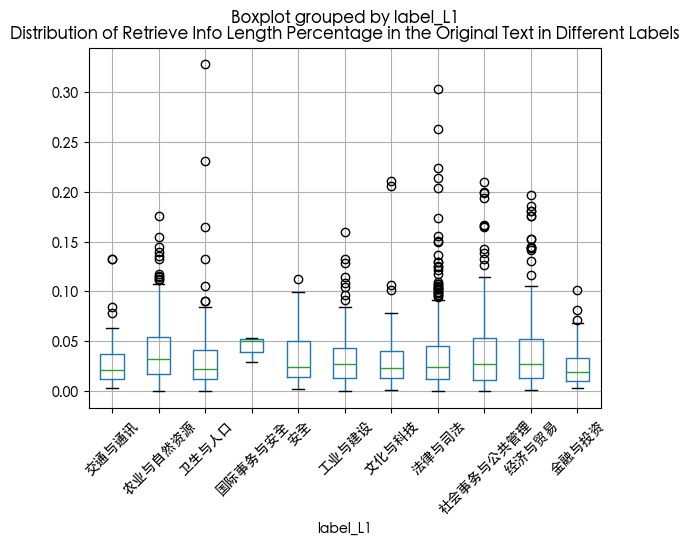

In [21]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=45)
plt.show()